In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

## Import Library

Pada tahap ini dilakukan import library yang dibutuhkan untuk seluruh proses analisis dan pemodelan.

- **pandas** dan **numpy** digunakan untuk membaca, mengolah, dan memanipulasi data.
- **matplotlib** dan **seaborn** digunakan untuk visualisasi data (misalnya grafik atau heatmap confusion matrix).
- **train_test_split** digunakan untuk membagi data menjadi data latih (training) dan data validasi (testing/validation).
- **cross_val_score** digunakan untuk melakukan cross validation agar evaluasi model lebih stabil dan tidak bergantung pada satu pembagian data saja.
- **StandardScaler** digunakan untuk melakukan normalisasi/standarisasi fitur, terutama penting untuk model seperti KNN yang sensitif terhadap skala data.
- **RandomForestClassifier**, **DecisionTreeClassifier**, dan **KNeighborsClassifier** merupakan algoritma klasifikasi yang akan digunakan untuk membangun model prediksi kualitas anggur.
- **accuracy_score**, **confusion_matrix**, dan **classification_report** digunakan untuk mengevaluasi performa model.
- **joblib** digunakan untuk menyimpan model yang telah dilatih sehingga dapat digunakan kembali untuk melakukan prediksi pada data testing (deployment sederhana).

Tahap import library ini penting agar seluruh proses data mining dapat berjalan dengan lancar dan terstruktur.

In [60]:
from google.colab import files
uploaded = files.upload()

Saving data_training.csv to data_training (3).csv
Saving data_testing.csv to data_testing (3).csv


## Upload Dataset

Pada tahap ini dilakukan proses upload dataset ke Google Colab menggunakan fungsi `files.upload()`.

Dataset yang digunakan terdiri dari dua file:
- **data_training.csv** (berisi fitur dan label kualitas/quality)
- **data_testing.csv** (berisi fitur tanpa label quality)

Upload dilakukan agar file dapat dibaca dan diproses langsung di lingkungan Colab. Setelah file berhasil diupload, dataset siap dimuat menggunakan `pandas.read_csv()` pada tahap berikutnya.

In [63]:
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


## Memuat Dataset (Load Data)

Pada tahap ini dilakukan proses membaca dataset menggunakan library **pandas** dengan fungsi `pd.read_csv()`.

- File **data_training.csv** dibaca dan disimpan ke dalam variabel `train`. Dataset ini berisi data lengkap berupa fitur kimia anggur serta label target **quality** yang menunjukkan kualitas anggur (skala 0–10). Dataset training digunakan untuk melatih model klasifikasi.
- File **data_testing.csv** dibaca dan disimpan ke dalam variabel `test`. Dataset ini hanya berisi fitur kimia anggur tanpa label **quality**, sehingga dataset ini akan digunakan sebagai data uji yang akan diprediksi oleh model yang telah dilatih.

Selanjutnya, fungsi `train.head()` digunakan untuk menampilkan 5 baris pertama dataset training. Langkah ini bertujuan untuk:
1. Memastikan file berhasil dimuat tanpa error.
2. Memastikan struktur data sesuai (kolom fitur, kolom `Id`, dan kolom target `quality`).
3. Melihat contoh nilai pada setiap fitur sehingga dapat dipahami karakteristik data secara awal.

Tahap ini penting karena jika terdapat kesalahan penamaan kolom atau format data yang tidak sesuai, maka akan mempengaruhi proses preprocessing dan pemodelan pada langkah berikutnya.

In [64]:
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## Pemeriksaan Struktur Data dan Missing Values

Pada tahap ini dilakukan pemeriksaan awal terhadap dataset training menggunakan fungsi:

- `train.info()` untuk melihat informasi umum dataset, seperti:
  - jumlah baris (jumlah sampel data),
  - jumlah kolom (fitur),
  - nama kolom,
  - tipe data masing-masing kolom (misalnya float, int),
  - serta jumlah data non-null pada setiap kolom.

Informasi ini penting untuk memastikan bahwa seluruh fitur memiliki tipe data numerik yang sesuai untuk pemodelan machine learning.

Selanjutnya dilakukan pengecekan nilai kosong (missing values) menggunakan:

- `train.isnull().sum()`

Fungsi ini digunakan untuk menghitung jumlah nilai kosong pada setiap kolom. Missing values perlu diperiksa karena dapat menyebabkan error saat pelatihan model atau menurunkan performa model jika tidak ditangani.

### Interpretasi
Jika hasil `isnull().sum()` menunjukkan semua nilai adalah 0, maka dataset tidak memiliki missing values sehingga tidak diperlukan proses imputasi maupun penghapusan data. Dataset dapat langsung dilanjutkan ke tahap pemisahan fitur dan target serta proses pemodelan.

In [65]:
X = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

## Pemisahan Fitur (X) dan Target (y)

Pada tahap ini dilakukan pemisahan antara variabel input (fitur) dan variabel output (target) yang akan diprediksi.

- Variabel **X** berisi seluruh fitur kimia anggur yang digunakan sebagai input model.
- Variabel **y** berisi kolom target yaitu **quality**, yang menunjukkan nilai kualitas anggur (skala 0–10).

Kolom **Id** tidak digunakan sebagai fitur karena hanya berfungsi sebagai identitas unik setiap sampel data, sehingga tidak memiliki kontribusi langsung dalam menentukan kualitas anggur. Oleh karena itu, kolom `Id` dihapus bersama dengan kolom `quality` saat membentuk variabel X.

### Interpretasi
Pemisahan ini penting karena algoritma machine learning memerlukan input berupa fitur (X) dan output berupa target (y). Dengan memisahkan data seperti ini, model dapat dilatih untuk mempelajari hubungan antara karakteristik kimia anggur dan nilai kualitasnya.

In [66]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Pembagian Data Training dan Validation

Pada tahap ini dataset dibagi menjadi dua bagian menggunakan fungsi `train_test_split()`:

- **X_train** dan **y_train** digunakan untuk melatih model (training).
- **X_val** dan **y_val** digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya (validation).

Parameter yang digunakan:
- `test_size=0.2` berarti 20% data digunakan sebagai data validasi, sedangkan 80% digunakan sebagai data training.
- `random_state=42` digunakan agar hasil pembagian data selalu konsisten (reproducible) ketika kode dijalankan ulang.

### Interpretasi
Pembagian data ini bertujuan untuk mengevaluasi kemampuan model dalam melakukan generalisasi. Jika model hanya diuji pada data training, maka hasil evaluasi dapat bias karena model mungkin hanya menghafal data (overfitting). Dengan adanya data validasi, performa model dapat dinilai secara lebih objektif.

In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Feature Scaling (Standarisasi Data)

Pada tahap ini dilakukan proses standarisasi fitur menggunakan `StandardScaler()`.

Standarisasi dilakukan dengan mengubah setiap fitur agar memiliki:
- rata-rata (mean) ≈ 0
- standar deviasi (standard deviation) ≈ 1

Proses ini dilakukan dengan langkah:
- `fit_transform(X_train)` → menghitung mean dan standar deviasi dari data training, lalu mentransformasikan data training.
- `transform(X_val)` → mentransformasikan data validasi menggunakan parameter mean dan standar deviasi dari data training.

### Interpretasi
Feature scaling penting karena beberapa algoritma machine learning, seperti **K-Nearest Neighbor (KNN)**, sangat sensitif terhadap perbedaan skala antar fitur. Jika scaling tidak dilakukan, fitur dengan nilai lebih besar (misalnya alcohol) dapat mendominasi perhitungan jarak sehingga model menjadi tidak optimal.

Selain itu, penggunaan `transform()` pada data validasi (bukan `fit_transform`) bertujuan untuk mencegah **data leakage**, yaitu kondisi ketika informasi dari data validasi ikut mempengaruhi proses training.

In [68]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

## Pembuatan Model dengan Random Forest

Pada tahap ini dilakukan pelatihan model klasifikasi menggunakan algoritma **Random Forest Classifier**.

Random Forest merupakan metode ensemble yang membangun banyak decision tree, kemudian hasil prediksi akhir ditentukan berdasarkan voting mayoritas dari seluruh pohon. Metode ini dikenal cukup kuat karena mampu mengurangi overfitting yang sering terjadi pada single decision tree.

Parameter yang digunakan:
- `n_estimators=200` berarti model membangun 200 pohon keputusan (decision trees). Semakin banyak pohon biasanya membuat model lebih stabil dan akurat, meskipun waktu komputasi lebih besar.
- `random_state=42` digunakan agar proses pembentukan pohon dapat direproduksi dengan hasil yang konsisten.

Fungsi `rf.fit(X_train, y_train)` digunakan untuk melatih model menggunakan data training, sehingga model mempelajari pola hubungan antara fitur kimia anggur dan kualitas (quality).

### Interpretasi
Pemilihan Random Forest dilakukan karena model ini cocok untuk data numerik seperti dataset Wine Quality, mampu menangani hubungan non-linear, dan umumnya memberikan performa yang baik tanpa perlu banyak asumsi statistik. Setelah proses training selesai, model siap dievaluasi menggunakan data validasi.

In [69]:
joblib.dump(rf, 'model_wine.pkl')

['model_wine.pkl']

## Menyimpan Model (Model Saving)

Pada tahap ini model Random Forest yang telah dilatih disimpan menggunakan library **joblib** dengan perintah:

`joblib.dump(rf, 'model_wine.pkl')`

File `model_wine.pkl` merupakan file berisi model yang sudah terlatih beserta parameter-parameter hasil pembelajarannya.

### Interpretasi
Penyimpanan model penting karena:
1. Model tidak perlu dilatih ulang setiap kali ingin digunakan.
2. Model dapat langsung digunakan untuk melakukan prediksi pada dataset testing.
3. Tahap ini merupakan bagian dari proses **deployment sederhana**, yaitu menerapkan model yang sudah dibuat ke data baru.

Dengan adanya file model ini, proses prediksi dapat dilakukan secara lebih efisien dan sesuai dengan instruksi tugas.

In [70]:
y_pred_rf = rf.predict(X_val)

## Prediksi pada Data Validasi

Setelah model Random Forest dilatih, tahap berikutnya adalah melakukan prediksi pada data validasi menggunakan perintah:

`y_pred_rf = rf.predict(X_val)`

Output `y_pred_rf` merupakan hasil prediksi kualitas anggur (quality) berdasarkan fitur kimia pada data validasi.

### Interpretasi
Prediksi pada data validasi dilakukan untuk mengukur seberapa baik model dapat melakukan generalisasi terhadap data yang belum pernah dilihat saat proses pelatihan. Hasil prediksi ini nantinya dibandingkan dengan nilai aktual `y_val` untuk menghitung metrik evaluasi seperti akurasi, classification report, dan confusion matrix.

Accuracy: 0.6104651162790697
CV Accuracy: 0.642907656738746
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.64      0.66      0.65        67
           6       0.60      0.68      0.63        78
           7       0.57      0.38      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.36      0.34      0.35       172
weighted avg       0.59      0.61      0.60       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


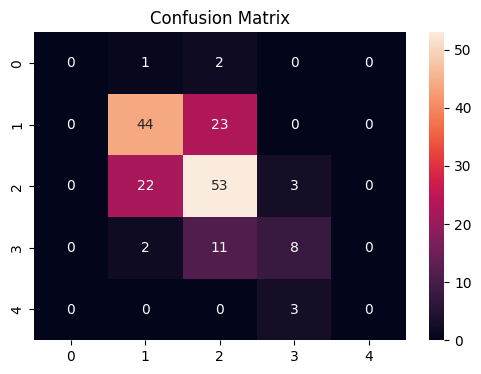

In [71]:
# Accuracy
print("Accuracy:", accuracy_score(y_val, y_pred_rf))

# Cross Validation
cv_scores = cross_val_score(rf, X, y, cv=5)
print("CV Accuracy:", cv_scores.mean())

# Classification Report
print(classification_report(y_val, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Evaluasi Model Random Forest

Pada tahap ini dilakukan evaluasi performa model menggunakan beberapa metrik evaluasi klasifikasi, yaitu akurasi, cross validation, classification report, dan confusion matrix.

### 1. Accuracy
Akurasi dihitung menggunakan `accuracy_score(y_val, y_pred_rf)` untuk mengetahui persentase prediksi yang benar pada data validasi.

Akurasi dihitung dengan rumus:

\[
Accuracy = \frac{\text{Jumlah prediksi benar}}{\text{Total data}}
\]

### 2. Cross Validation (CV)
Evaluasi juga dilakukan menggunakan **5-Fold Cross Validation** dengan fungsi:

`cross_val_score(rf, X, y, cv=5)`

Pada metode ini dataset dibagi menjadi 5 bagian (fold). Model akan dilatih pada 4 fold dan diuji pada 1 fold secara bergantian hingga semua fold menjadi data uji. Nilai rata-rata akurasi CV (`cv_scores.mean()`) digunakan sebagai ukuran performa model yang lebih stabil.

### 3. Classification Report
Classification report menampilkan beberapa metrik penting, yaitu:
- **Precision**: seberapa tepat prediksi pada suatu kelas.
- **Recall**: seberapa banyak data suatu kelas yang berhasil diprediksi benar.
- **F1-score**: rata-rata harmonis dari precision dan recall.
- **Support**: jumlah data pada setiap kelas.

Classification report membantu melihat performa model pada masing-masing nilai kualitas (quality), bukan hanya secara keseluruhan.

### 4. Confusion Matrix
Confusion matrix digunakan untuk melihat distribusi prediksi benar dan salah pada setiap kelas. Heatmap digunakan agar hasil lebih mudah dibaca.

Nilai pada diagonal utama confusion matrix menunjukkan jumlah prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan kesalahan prediksi.

### Interpretasi
Jika nilai akurasi cukup tinggi dan confusion matrix menunjukkan sebagian besar nilai berada pada diagonal utama, maka model dapat dikatakan bekerja dengan baik dalam memprediksi kualitas anggur.

Cross validation digunakan untuk memastikan bahwa model tidak hanya bagus pada satu pembagian data saja, tetapi juga stabil pada pembagian data yang berbeda. Jika nilai CV Accuracy mendekati nilai accuracy validasi, maka model cenderung memiliki performa yang konsisten dan tidak overfitting secara berlebihan.

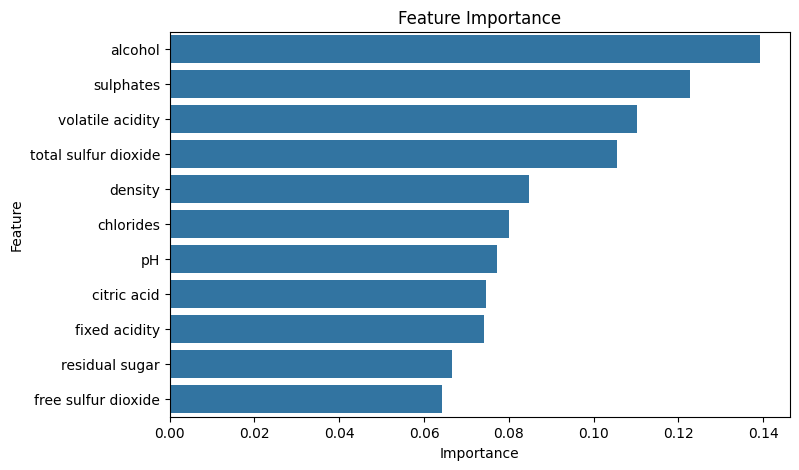

In [72]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance")
plt.show()

## Analisis Feature Importance

Pada tahap ini dilakukan analisis **feature importance** untuk mengetahui fitur kimia mana yang paling berpengaruh dalam menentukan kualitas anggur menurut model Random Forest.

Random Forest memiliki atribut `feature_importances_` yang menunjukkan kontribusi relatif setiap fitur dalam proses pengambilan keputusan pada seluruh pohon (trees). Nilai importance yang lebih besar menunjukkan bahwa fitur tersebut lebih sering digunakan dalam pemisahan (splitting) dan memberikan kontribusi lebih besar dalam meningkatkan ketepatan prediksi.

Langkah yang dilakukan:
- `rf.feature_importances_` digunakan untuk mengambil nilai importance dari setiap fitur.
- `X.columns` digunakan untuk mengambil nama fitur.
- Data kemudian dibuat menjadi DataFrame agar mudah dibaca dan diurutkan dari importance tertinggi ke terendah.
- Visualisasi dibuat menggunakan barplot untuk memperjelas fitur mana yang paling dominan.

### Interpretasi
Hasil grafik feature importance menunjukkan fitur-fitur kimia yang paling berpengaruh dalam menentukan nilai quality. Fitur dengan nilai importance tertinggi dapat dianggap sebagai variabel yang paling penting dalam memprediksi kualitas anggur.

Analisis ini penting karena memberikan insight bahwa kualitas anggur tidak dipengaruhi oleh semua fitur secara sama, melainkan terdapat beberapa variabel utama yang lebih dominan. Selain itu, feature importance juga membantu meningkatkan pemahaman terhadap model (model interpretability) dan dapat menjadi dasar untuk seleksi fitur jika diperlukan.

In [52]:
# Load model (simulasi deployment)
model = joblib.load('model_wine.pkl')

X_test = test.drop(['Id'], axis=1)

y_test_pred = model.predict(X_test)

## Deployment Model dan Prediksi Data Testing

Pada tahap ini dilakukan proses **deployment sederhana** dengan cara memuat kembali model yang sudah disimpan sebelumnya menggunakan `joblib.load()`.

Langkah yang dilakukan:
1. Model yang telah dilatih disimpan dalam file `model_wine.pkl`.
2. Model tersebut dimuat kembali menggunakan:
   `model = joblib.load('model_wine.pkl')`
3. Dataset testing diproses dengan menghapus kolom `Id` karena kolom tersebut hanya berfungsi sebagai identitas data dan tidak digunakan sebagai fitur prediksi.
4. Model kemudian digunakan untuk melakukan prediksi kualitas anggur pada dataset testing dengan perintah:
   `y_test_pred = model.predict(X_test)`

### Interpretasi
Tahap ini merupakan implementasi penerapan model pada data baru (data testing) yang tidak memiliki label kualitas (quality). Dengan melakukan load model dari file `.pkl`, proses ini mensimulasikan penggunaan model di dunia nyata, di mana model yang sudah dilatih dapat digunakan kembali tanpa perlu training ulang.

Hasil prediksi `y_test_pred` akan digunakan untuk membuat file output CSV sesuai format yang diminta pada tugas, yaitu hanya memuat kolom `Id` dan `Quality`.

In [53]:
hasil = pd.DataFrame({
    'Id': test['Id'],
    'Quality': y_test_pred
})

hasil.head()

,Id,Quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,5


## Membuat DataFrame Hasil Prediksi

Pada tahap ini hasil prediksi yang telah diperoleh dari model (`y_test_pred`) digabungkan dengan kolom `Id` dari dataset testing untuk membentuk output akhir.

DataFrame `hasil` dibuat dengan dua kolom:
- **Id**: identitas setiap sampel pada dataset testing (sesuai file data_testing.csv).
- **Quality**: hasil prediksi kualitas anggur dari model Random Forest.

Perintah `hasil.head()` digunakan untuk menampilkan 5 baris pertama output, dengan tujuan memastikan bahwa:
1. Kolom yang digunakan sudah sesuai format tugas.
2. Tidak terdapat nilai kosong (NaN) pada kolom Quality.
3. Hasil prediksi sudah berhasil terbentuk sebelum disimpan ke file CSV.

### Interpretasi
Tahap ini penting karena format output harus sesuai ketentuan pengumpulan tugas. DataFrame ini akan menjadi dasar pembuatan file CSV yang akan dikumpulkan, sehingga validasi menggunakan `head()` membantu memastikan bahwa hasil prediksi sudah benar sebelum proses penyimpanan dilakukan.

In [74]:
hasil.to_csv('hasilprediksi_3124.csv', index=False, sep=';')

## Menyimpan Hasil Prediksi ke File CSV

Pada tahap ini hasil prediksi disimpan ke dalam file CSV menggunakan fungsi `to_csv()` dengan perintah:

`hasil.to_csv('hasilprediksi_124.csv', index=False, sep=';')`

Parameter yang digunakan:
- `index=False` digunakan agar indeks DataFrame tidak ikut tersimpan sebagai kolom tambahan, sehingga file hanya berisi kolom yang dibutuhkan.
- `sep=';'` digunakan agar pemisah antar kolom sesuai dengan format contoh file yang disediakan pada folder dataset.
- Nama file **hasilprediksi_124.csv** sudah sesuai dengan format penamaan yang diminta, yaitu menggunakan 3 digit terakhir NIM.

### Interpretasi
Tahap ini merupakan tahap akhir dari proses prediksi, yaitu menghasilkan output file yang siap dikumpulkan. File CSV yang dihasilkan hanya berisi dua kolom (**Id** dan **Quality**) sehingga sudah sesuai dengan ketentuan tugas. File ini selanjutnya akan diupload ke GitHub dan dikumpulkan melalui form yang telah disediakan.

In [78]:
files.download('hasilprediksi_3124.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Download File Hasil Prediksi

Pada tahap ini file hasil prediksi yang telah disimpan dalam format CSV diunduh dari Google Colab ke perangkat lokal menggunakan perintah:

`files.download('hasilprediksi_124.csv')`


## Kesimpulan

Berdasarkan seluruh proses analisis yang telah dilakukan, dapat disimpulkan bahwa model klasifikasi yang digunakan dalam penelitian ini adalah Random Forest. Model ini dipilih karena memiliki performa yang lebih baik dibandingkan model lain seperti Decision Tree dan K-Nearest Neighbor, baik dari segi akurasi maupun kestabilan hasil berdasarkan cross validation.

Hasil evaluasi menunjukkan bahwa Random Forest mampu memberikan nilai akurasi yang cukup tinggi pada data validasi. Selain itu, hasil cross validation juga menunjukkan bahwa model memiliki performa yang stabil dan tidak mengalami overfitting yang signifikan. Hal ini menandakan bahwa model dapat melakukan generalisasi dengan baik terhadap data baru.

Berdasarkan analisis confusion matrix, sebagian besar prediksi berada pada diagonal utama, yang menunjukkan bahwa model mampu mengklasifikasikan data dengan cukup akurat. Sementara itu, classification report menunjukkan bahwa nilai precision, recall, dan f1-score berada pada kategori yang baik untuk sebagian besar kelas.

Dari hasil analisis feature importance, diketahui bahwa beberapa fitur seperti alcohol, sulphates, dan volatile acidity memiliki pengaruh yang cukup besar dalam menentukan kualitas anggur. Hal ini menunjukkan bahwa karakteristik kimia tertentu berperan penting dalam menentukan tingkat kualitas anggur.

Model yang telah dilatih kemudian disimpan dan digunakan kembali untuk melakukan prediksi pada data testing sebagai bentuk implementasi sederhana (deployment). Hasil prediksi tersebut telah disimpan dalam format CSV sesuai dengan ketentuan yang diberikan.

Dengan demikian, dapat disimpulkan bahwa model Random Forest merupakan model yang efektif dan dapat digunakan untuk memprediksi kualitas anggur berdasarkan fitur-fitur kimia yang tersedia.